# Statistics about the data set

## Read in the data from the folder data

In [2]:
import pandas as pd

df = pd.read_csv('data/metadata.csv')
df.head()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


### Code from exercise 01_introduction

DATASET OVERVIEW


Dataset shape: 2298 rows, 26 columns

Columns: ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']
DATA TYPES

patient_id              object
lesion_id                int64
smoke                   object
drink                   object
background_father       object
background_mother       object
age                      int64
pesticide               object
gender                  object
skin_cancer_history     object
cancer_history          object
has_piped_water         object
has_sewage_system       object
fitspatrick            float64
region                  object
diameter_1             float64
diameter_2             float64
diagnostic              object
itch                

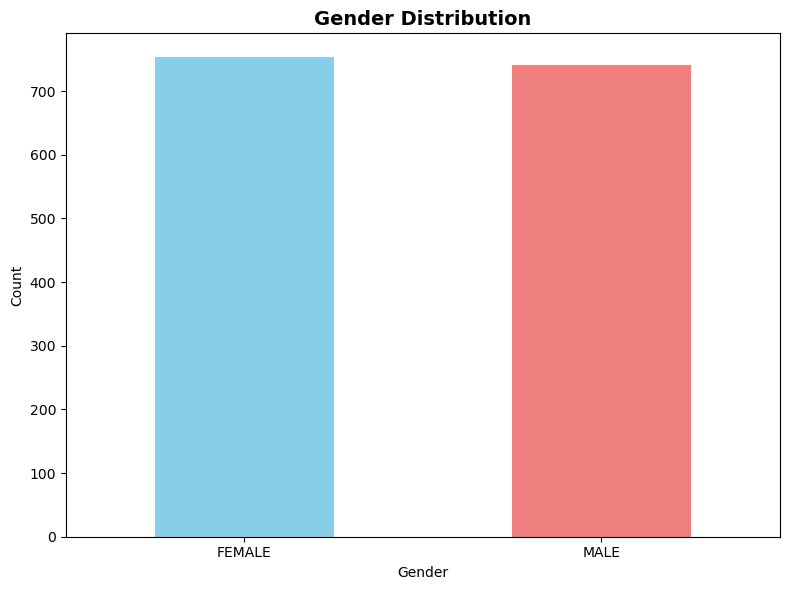


Age Statistics:
count    2298.000000
mean       60.464752
std        15.894866
min         6.000000
25%        52.000000
50%        62.000000
75%        72.000000
max        94.000000
Name: age, dtype: float64


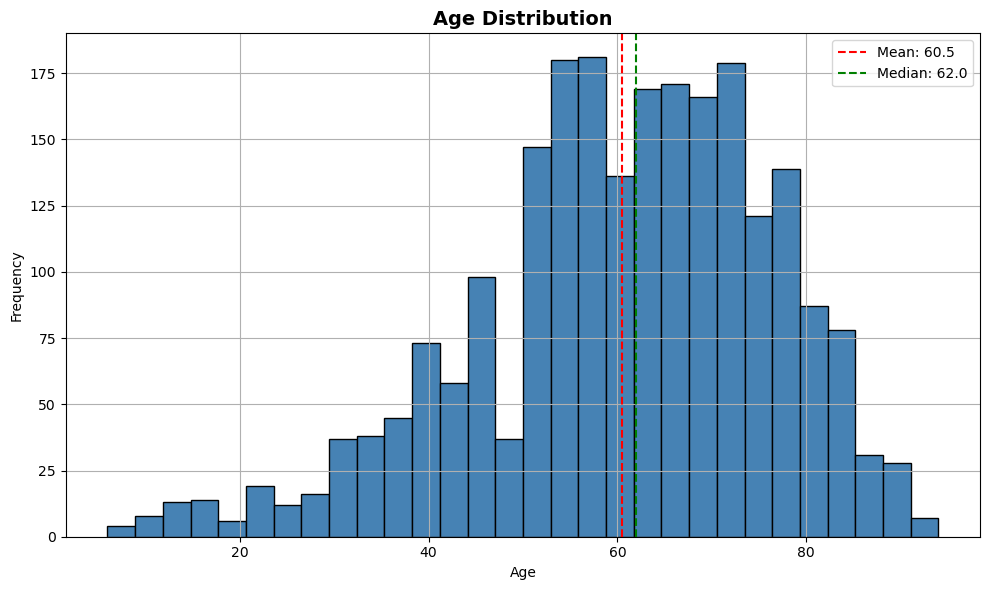


Diagnostic Distribution:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


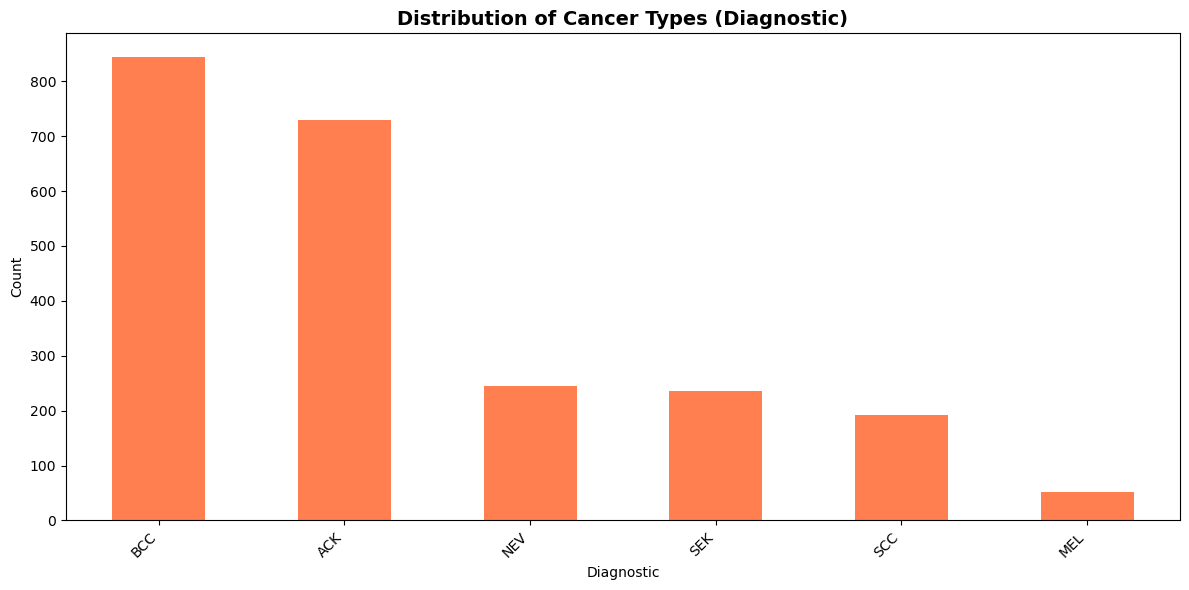

/var/folders/gd/3qn4sczn2f73j1m12m7h5t6h0000gn/T/ipykernel_59824/1090289449.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnostic', y='age', ax=axes[1], palette='Set2')


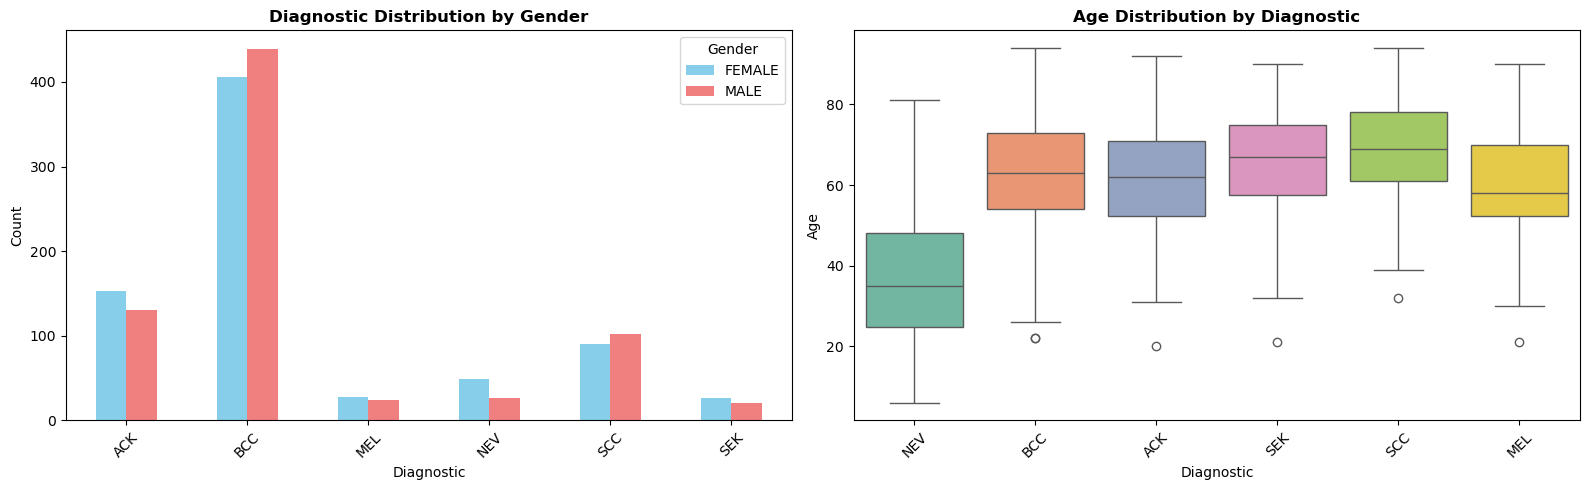

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#df = df.drop(columns=['Unnamed: 0'])

# Step 1: Dataset Overview

print("DATASET OVERVIEW\n")

print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

# Step 2: Data Types

print("DATA TYPES\n")

print(df.dtypes)

# Step 3: Missing Values Analysis

print("MISSING VALUES ANALYSIS\n")

missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

# Step 4: Summary Statistics

print("SUMMARY STATISTICS\n")

print(df.describe())

# Step 5: Categorical Features Overview

print("CATEGORICAL FEATURES\n")

categorical_columns = df.select_dtypes(include=['object', 'bool']).columns
for col in categorical_columns:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())

# Step 6: Duplicates Check
duplicates = df.duplicated().sum()

print("DUPLICATES")

print(f"Number of duplicate rows: {duplicates}\n")


print("VISUALIZATIONS\n")


# Gender Distribution
if 'gender' in df.columns:
    print("\nGender Distribution:")
    print(df['gender'].value_counts())
    
    plt.figure(figsize=(8, 6))
    df['gender'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
    plt.title('Gender Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Age Distribution
if 'age' in df.columns:
    print("\nAge Statistics:")
    print(df['age'].describe())
    
    plt.figure(figsize=(10, 6))
    df['age'].hist(bins=30, edgecolor='black', color='steelblue')
    plt.title('Age Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
    plt.axvline(df['age'].median(), color='green', linestyle='--', label=f'Median: {df["age"].median():.1f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Diagnostic (Cancer Type) Distribution
if 'diagnostic' in df.columns:
    print("\nDiagnostic Distribution:")
    print(df['diagnostic'].value_counts())
    
    plt.figure(figsize=(12, 6))
    diagnostic_counts = df['diagnostic'].value_counts()
    diagnostic_counts.plot(kind='bar', color='coral')
    plt.title('Distribution of Cancer Types (Diagnostic)', fontsize=14, fontweight='bold')
    plt.xlabel('Diagnostic')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Diagnostic vs Gender and Diagnostic vs Age
if 'diagnostic' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. Diagnostic vs Gender
    if 'gender' in df.columns:
        crosstab = pd.crosstab(df['diagnostic'], df['gender'])
        crosstab.plot(kind='bar', ax=axes[0], color=['skyblue', 'lightcoral'])
        axes[0].set_title('Diagnostic Distribution by Gender', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Diagnostic')
        axes[0].set_ylabel('Count')
        axes[0].legend(title='Gender')
        axes[0].tick_params(axis='x', rotation=45)
    
    # 2. Diagnostic vs Age
    if 'age' in df.columns:
        sns.boxplot(data=df, x='diagnostic', y='age', ax=axes[1], palette='Set2')
        axes[1].set_title('Age Distribution by Diagnostic', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Diagnostic')
        axes[1].set_ylabel('Age')
        axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

### Show img, mask and overlay side by side

In [5]:
n = df.shape[0]
imglist = []
for x in range(n):
    imglist.append(df.iloc[x]["img_id"])

count = 0

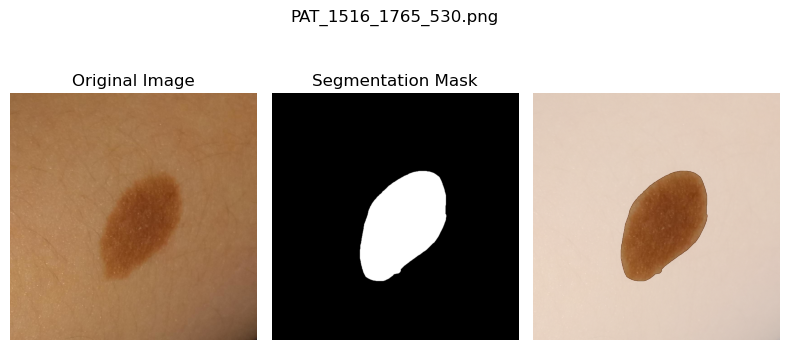

In [6]:
img_path = "data/imgs/"
mask_path = "data/masks/"


for patient in df.itertuples():
    img = patient.img_id


# Load the image/mask
file_im = img_path + imglist[count]
file_mask = (mask_path + imglist[count]).replace(".png", "_mask.png")

im = plt.imread(file_im)
mask = plt.imread(file_mask)

# View image/mask
im = plt.imread(file_im)
mask = plt.imread(file_mask)

# Display im and mask side by side
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

# Display im
axes[0].imshow(im)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Display mask
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Segmentation Mask')
axes[1].axis('off')

axes[2].imshow(im)
masked_array = np.ma.masked_where(mask == 1, mask)
axes[2].imshow(masked_array, cmap = "Reds", alpha=0.7) 
#alpha value can be change to focus more on lesion, but think its good to have some oppacity
axes[2].axis('off')


fig.suptitle(f'{imglist[count]}')

plt.tight_layout()
plt.show()

count += 1